# EXAMEN GRUPAL — Semanas 9 y 10
## Modelado Secuencial con RNN, LSTM y GRU

**Curso:** Inteligencia Artificial aplicada a la Ingenieria  
**Docente:** M.Sc. Ing. Jairo Pinedo Taquia
**Modalidad:** Grupal — 4 integrantes  
**Duracion:** 2 horas  
**Escala de calificacion:** 0 a 20 puntos

---

### Datos del grupo

| Campo | Completar |
|-------|-----------|
| Integrante 1 (Datos) | Vilchez Rody |
| Integrante 2 (RNN) | Velasquez Christian |
| Integrante 3 (LSTM/GRU) | Lazaro Luis |
| Integrante 4 (Comunicacion) | — (grupo de 3 integrantes) |
| Seccion | 18522 |
| Fecha | 17/06/2026 |

---

### Descripcion del caso

Una planta industrial opera una bomba de agua cuyo comportamiento es registrado por 52 sensores de campo con frecuencia de un minuto durante varios meses. El sistema etiqueta cada registro con uno de tres estados operativos:

- `NORMAL`: operacion dentro de parametros
- `RECOVERING`: degradacion incipiente, señal de alerta
- `BROKEN`: falla confirmada

El area de confiabilidad necesita un modelo que anticipe el estado `RECOVERING` antes de que ocurra la falla, para programar intervenciones preventivas en lugar de correctivas.

El grupo actua como equipo de ingenieria de datos contratado para entregar un prototipo funcional y una presentacion ejecutiva.

**Dataset:** [https://www.kaggle.com/datasets/nphantawee/pump-sensor-data](https://www.kaggle.com/datasets/nphantawee/pump-sensor-data)  
Archivo: `sensor.csv`

---

### Estructura del examen y puntaje

| Fase | Contenido | Puntos | Tiempo estimado |
|------|-----------|--------|----------------|
| 1 | Exploracion y preparacion de datos | 4 | 20 min |
| 2 | Implementacion de modelos | 9 | 60 min |
| 3 | Analisis de gradientes (teoria) | 3 | 10 min |
| 4 | Presentacion ejecutiva | 4 | 10 min |
| **Total** | | **20** | **100 min** |

**Bonus:** Dashboard interactivo con Streamlit (+2 pts fuera del tiempo del examen)

---

### Instrucciones generales

1. Ejecutar las celdas en orden. No modificar las celdas marcadas como `[CELDA BASE — NO MODIFICAR]`.
2. Completar unicamente las celdas marcadas con `[COMPLETAR]`.
3. Las celdas Markdown de respuesta escrita deben editarse haciendo doble clic sobre ellas.
4. Al finalizar, compartir el notebook ejecutado via Google Drive con el docente.
5. Cualquier integrante puede ser preguntado sobre cualquier parte del notebook durante la exposicion oral.

---
## CELDA BASE — Configuracion e instalacion
### NO MODIFICAR

In [1]:
# ============================================================
# CELDA BASE — NO MODIFICAR
# Instalacion de dependencias y carga del dataset
# ============================================================

# Instalar kaggle si no esta disponible en el entorno
!pip install kaggle -q

import numpy as np                        # algebra lineal y operaciones numericas
import pandas as pd                       # manejo de DataFrames
import matplotlib.pyplot as plt           # visualizacion estatica
import matplotlib.patches as mpatches    # parches de color para leyendas manuales
import warnings                           # control de advertencias
warnings.filterwarnings('ignore')         # suprimir advertencias no criticas

from sklearn.preprocessing import StandardScaler, LabelEncoder   # normalizacion y codificacion
from sklearn.metrics import classification_report, confusion_matrix  # evaluacion del modelo
from sklearn.utils.class_weight import compute_class_weight          # pesos para clases desbalanceadas

import tensorflow as tf                                   # framework de deep learning
from tensorflow.keras.models import Sequential            # modelo secuencial de capas
from tensorflow.keras.layers import (                     # capas disponibles
    SimpleRNN, LSTM, GRU, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping      # detener entrenamiento si no mejora

# Configuracion de graficos
plt.rcParams['figure.dpi']       = 100
plt.rcParams['font.size']        = 10
plt.rcParams['axes.titlesize']   = 11
plt.rcParams['axes.titleweight'] = 'bold'

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print("Dependencias cargadas correctamente.")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

TensorFlow version: 2.21.0
Dependencias cargadas correctamente.


In [2]:
# ============================================================
# CELDA BASE — NO MODIFICAR
# Carga del dataset desde Kaggle o subida manual
# ============================================================

# OPCION A: descarga automatica con API de Kaggle
# Requiere tener kaggle.json configurado en /root/.kaggle/
# Instrucciones: https://www.kaggle.com/docs/api
#
# import os
# from google.colab import files
# files.upload()   # subir kaggle.json cuando aparezca el dialogo
# os.makedirs('/root/.kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 600)
# !kaggle datasets download -d nphantawee/pump-sensor-data --unzip

# OPCION B: subida manual (recomendada en examen)
# 1. Descargar sensor.csv desde: kaggle.com/datasets/nphantawee/pump-sensor-data
# 2. En Colab: panel izquierdo > icono de carpeta > subir archivo
# 3. Ejecutar la celda siguiente

try:
    df_raw = pd.read_csv('sensor.csv')                    # cargar el archivo CSV
    df_raw.columns = df_raw.columns.str.strip()           # eliminar espacios en nombres de columnas
    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])  # convertir timestamp a datetime
    df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)  # ordenar cronologicamente
    print(f"Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
    print(f"Rango temporal: {df_raw['timestamp'].min()} a {df_raw['timestamp'].max()}")
    print(f"\nDistribucion de estados (machine_status):")
    print(df_raw['machine_status'].value_counts())
    print(f"\nPorcentaje de cada estado:")
    print((df_raw['machine_status'].value_counts(normalize=True)*100).round(2))
except FileNotFoundError:
    print("ERROR: archivo sensor.csv no encontrado.")
    print("Subir el archivo manualmente siguiendo las instrucciones de OPCION B.")

Dataset cargado: 220,320 filas x 55 columnas
Rango temporal: 2018-04-01 00:00:00 a 2018-08-31 23:59:00

Distribucion de estados (machine_status):
machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

Porcentaje de cada estado:
machine_status
NORMAL        93.43
RECOVERING     6.57
BROKEN         0.00
Name: proportion, dtype: float64


---
## FASE 1 — Exploracion y preparacion de datos
**Responsable principal:** Integrante 1  
**Puntaje:** 4 puntos  
**Tiempo estimado:** 20 minutos

### Rubrica

| Criterio | Puntos |
|----------|--------|
| Seleccion correcta de sensores (umbral de nulos aplicado) | 0.5 |
| Tratamiento de NaN con justificacion correcta | 0.5 |
| Grafico de series temporales con coloreado por estado | 1.0 |
| Deteccion y decision sobre la clase BROKEN | 1.0 |
| Justificacion escrita del modelado secuencial | 1.0 |
| **Total Fase 1** | **4.0** |

In [3]:
# ============================================================
# FASE 1 — Tarea 1.1 [COMPLETAR]
# Seleccion de sensores y tratamiento de valores nulos
# ============================================================

# Paso 1: Identificar columnas de sensores (comienzan con 'sensor')
#         y calcular el % de valores nulos de cada una.
umbral_nulos   = 0.05  # conservar sensores con < 5% de valores faltantes
todos_sensores = [col for col in df_raw.columns if col.startswith('sensor')]

# fraccion de NaN por sensor
pct_nulos = df_raw[todos_sensores].isna().mean()

# conservar solo los sensores por debajo del umbral
sensores_validos = pct_nulos[pct_nulos < umbral_nulos].index.tolist()

print(f"Sensores totales: {len(todos_sensores)}")
print(f"Sensores conservados (< {umbral_nulos*100:.0f}% nulos): {len(sensores_validos)}")
print("\nSensores descartados por exceso de nulos:")
for s, p in pct_nulos[pct_nulos >= umbral_nulos].sort_values(ascending=False).items():
    print(f"  {s}: {p*100:.1f}% nulos")

# Paso 2: Crear copia de trabajo con timestamp, etiqueta y sensores validos
df = df_raw[['timestamp', 'machine_status'] + sensores_validos].copy()

# Paso 3: Imputar NaN con forward fill seguido de backward fill.
# Justificacion: en una serie temporal de sensores, propagar el ultimo
# valor conocido (ffill) es mejor estimador que la media global porque
# preserva la tendencia local de la senal; el bfill final cubre los NaN
# iniciales que no tienen un valor previo del cual propagarse.
df[sensores_validos] = df[sensores_validos].ffill().bfill()

# Paso 4: Verificar que no quedan nulos
print(f"\nNulos restantes tras imputacion: {df[sensores_validos].isna().sum().sum()}")

Sensores totales: 52
Sensores conservados (< 5% nulos): 49

Sensores descartados por exceso de nulos:
  sensor_15: 100.0% nulos
  sensor_50: 35.0% nulos
  sensor_51: 7.0% nulos



Nulos restantes tras imputacion: 0


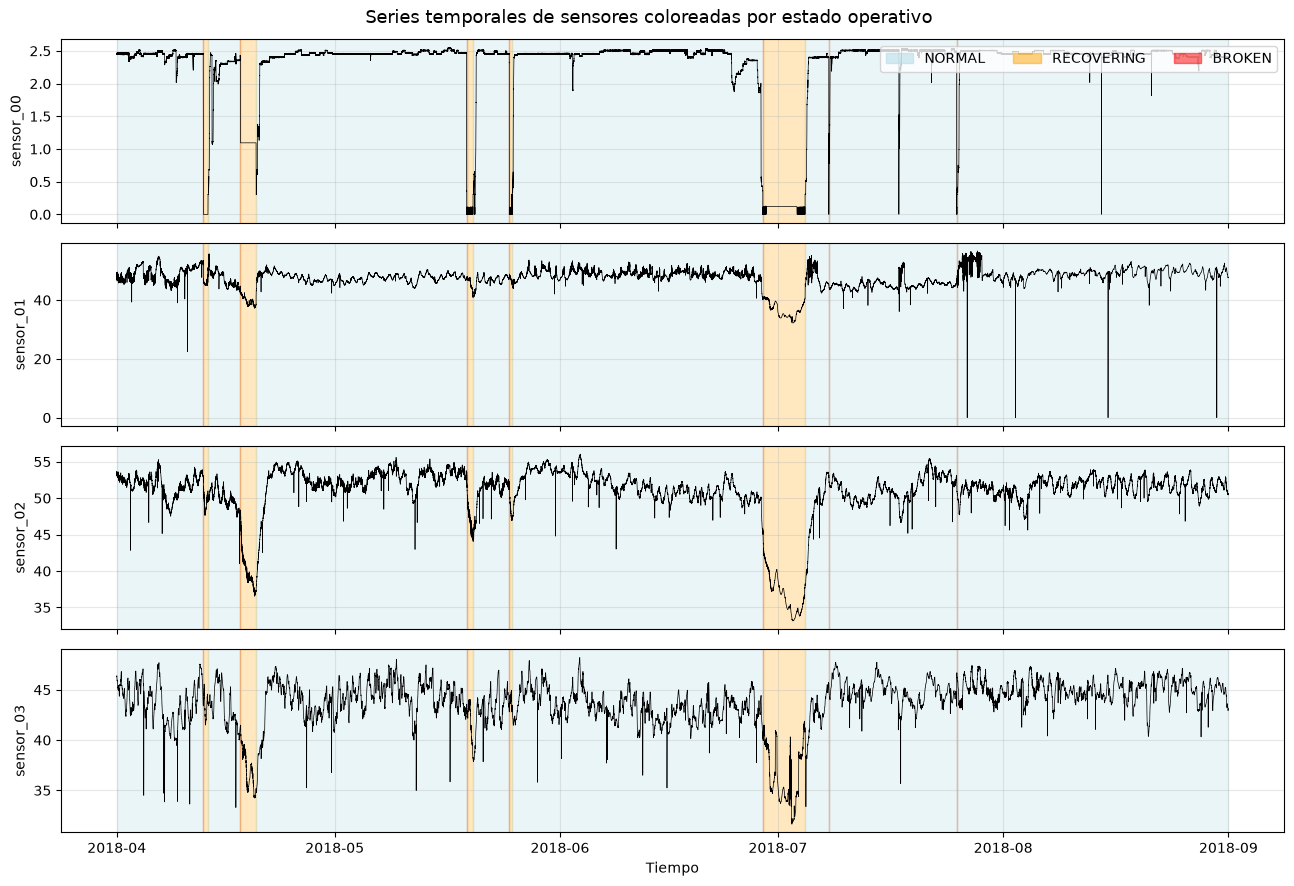

In [4]:
# ============================================================
# FASE 1 — Tarea 1.2 [COMPLETAR]
# Visualizacion de series temporales por estado operativo
# ============================================================

import os
os.makedirs('results', exist_ok=True)   # carpeta para guardar las figuras

# Paso 1: elegir 4 sensores representativos
SENSORES_VIZ = sensores_validos[:4]

# Construir los intervalos (segmentos) contiguos de un mismo machine_status.
# machine_status solo cambia en los pocos episodios de falla, asi que se
# obtienen unas pocas franjas en lugar de pintar punto por punto.
status  = df['machine_status'].values
tiempo  = df['timestamp'].values
cambios = np.where(status[1:] != status[:-1])[0] + 1
limites = np.concatenate(([0], cambios, [len(status)]))
segmentos = [(tiempo[limites[i]], tiempo[limites[i + 1] - 1], status[limites[i]])
             for i in range(len(limites) - 1)]

colores_estado = {'NORMAL': 'lightblue', 'RECOVERING': 'orange', 'BROKEN': 'red'}

# Paso 2-3: un subplot por sensor, con el fondo coloreado por estado (axvspan)
fig, axes = plt.subplots(len(SENSORES_VIZ), 1, figsize=(13, 9), sharex=True)
fig.suptitle('Series temporales de sensores coloreadas por estado operativo', fontsize=13)

for ax, sensor in zip(axes, SENSORES_VIZ):
    ax.plot(df['timestamp'], df[sensor], color='black', linewidth=0.5)
    for t0, t1, est in segmentos:
        ax.axvspan(t0, t1, alpha=0.25, color=colores_estado.get(est, 'gray'))
    ax.set_ylabel(sensor)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Tiempo')

# Paso 4: leyenda manual de estados
parches = [mpatches.Patch(color=c, alpha=0.5, label=e) for e, c in colores_estado.items()]
axes[0].legend(handles=parches, loc='upper right', ncol=3)

plt.tight_layout()
plt.savefig('results/fase1_series_temporales.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
# ============================================================
# FASE 1 — Tarea 1.3 [COMPLETAR]
# Decision sobre la clase BROKEN y codificacion de etiquetas
# ============================================================

# Paso 1: Contar cuantos registros tiene cada clase
print("Distribucion original de machine_status:")
print(df['machine_status'].value_counts())

# Paso 2: Decision del grupo -> OPCION A (fusionar BROKEN con RECOVERING)
# Motivo: BROKEN solo aparece en 7 registros (marca el instante exacto de la
# falla ya consumada). Son demasiados pocos ejemplos para aprender una clase
# propia y, ademas, BROKEN representa la misma condicion de "anomalia" que se
# quiere anticipar. Por eso se fusiona con RECOVERING y el problema se vuelve
# BINARIO: NORMAL (0) vs ANOMALIA (1).  (Ver justificacion escrita 1.3.)

# Paso 3: Codificar etiquetas como enteros
df['estado_cod'] = df['machine_status'].map({'NORMAL': 0, 'RECOVERING': 1, 'BROKEN': 1})

print("\nDistribucion final de clases (0=Normal, 1=Anomalia):")
print(df['estado_cod'].value_counts())
print(f"\nProporcion de la clase anomalia: {df['estado_cod'].mean()*100:.2f}%")

# Guardar el numero de clases para usar en el modelo
N_CLASES = df['estado_cod'].nunique()
print(f"Numero de clases: {N_CLASES}")

Distribucion original de machine_status:
machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

Distribucion final de clases (0=Normal, 1=Anomalia):
estado_cod
0    205836
1     14484
Name: count, dtype: int64

Proporcion de la clase anomalia: 6.57%
Numero de clases: 2


### Respuesta escrita 1.3 — Decision sobre la clase BROKEN

**Opcion elegida: A** — Fusionar `BROKEN` con `RECOVERING` en una unica clase **ANOMALIA**, dejando el problema como clasificacion **binaria** (`NORMAL` = 0 vs `ANOMALIA` = 1).

**Justificacion:**

La clase `BROKEN` aparece en solo **7 de los 220 320 registros** (≈ 0.003 %). Con tan pocos ejemplos es imposible que una red aprenda un patron estadistico propio de esa clase: cualquier particion train/test dejaria 0 o 1 muestras de `BROKEN` en validacion, las metricas serian puro ruido y el modelo memorizaria en vez de generalizar. Ademas, `BROKEN` no es un estado que se quiera "predecir con anticipacion": marca el **instante exacto de la falla ya consumada**, cuando el dano ya ocurrio; el objetivo de negocio es detectar la **degradacion previa**, que es justamente lo que captura `RECOVERING`.

Por eso se fusiona `BROKEN` dentro de `RECOVERING` formando una sola clase de anomalia. La consecuencia directa es que el problema deja de ser multiclase (3 estados) y pasa a ser **binario** (Normal vs Anomalia): la capa de salida usa una neurona con activacion *sigmoid* y perdida *binary_crossentropy*. Aun asi, las clases quedan muy desbalanceadas (≈ 6.6 % anomalia), por lo que se compensa con `class_weight` en el entrenamiento.

### Respuesta escrita 1.4 — Por que se necesita modelado secuencial

Un clasificador clasico como **Random Forest aplicado fila por fila** decide el estado mirando unicamente los 49 valores de los sensores en el instante `t`, sin ninguna nocion de lo que ocurrio antes. El problema es que el estado `RECOVERING` **no se define por un valor anomalo puntual, sino por la evolucion de la senal en el tiempo**: una vibracion que crece lentamente, una temperatura que sube de forma sostenida o una presion que oscila cada vez mas. Un solo instante de esos valores puede ser indistinguible de la operacion normal —el valor absoluto todavia cae dentro del rango "sano"— y lo que delata la degradacion es la **tendencia y el contexto historico** de los ultimos minutos.

Por eso se necesita un modelo **secuencial** (RNN / LSTM / GRU): estas arquitecturas reciben como entrada una **ventana de los ultimos `LOOKBACK` pasos de tiempo** y mantienen un estado oculto que resume la dinamica reciente. Asi pueden aprender **dependencias temporales** —"si la vibracion lleva 20 minutos subiendo, se aproxima una falla"— que un modelo sin memoria, que trata cada fila como un punto independiente e intercambiable, es incapaz de capturar. En terminos del negocio, el modelo secuencial es lo que permite **anticipar** la falla en lugar de solo reaccionar cuando un sensor ya cruzo un umbral critico.

---
## FASE 2 — Implementacion de modelos
**Responsables:** Integrantes 1, 2 y 3  
**Puntaje:** 9 puntos  
**Tiempo estimado:** 60 minutos

### Rubrica

| Criterio | Puntos |
|----------|--------|
| Construccion de ventanas temporales sin data leakage | 2.0 |
| Modelo RNN funcional con curvas de entrenamiento | 2.0 |
| Modelo LSTM o GRU funcional | 2.0 |
| Comparacion de metricas con enfasis en clase anomalia | 2.0 |
| Justificacion tecnica LSTM vs GRU | 1.0 |
| **Total Fase 2** | **9.0** |

In [6]:
# ============================================================
# FASE 2 — Bloque A: Construccion de ventanas temporales
# Responsable: Integrante 1
# [COMPLETAR]
# ============================================================

# Una ventana temporal toma los ultimos LOOKBACK pasos de tiempo
# para predecir el estado en el instante siguiente.
# Ejemplo con LOOKBACK=3:
#   X[i] = [mediciones en t-3, t-2, t-1]  ->  y[i] = estado en t

LOOKBACK = 30   # usar los ultimos 30 minutos de datos

# Paso 2: Funcion para construir secuencias (X de forma [n, lookback, n_features])
def crear_secuencias(X, y, lookback):
    """
    Convierte arrays planos en secuencias para modelos recurrentes.

    Parametros:
        X        : array normalizado de shape (n_muestras, n_features)
        y        : array de etiquetas de shape (n_muestras,)
        lookback : numero de pasos de tiempo en cada ventana

    Retorna:
        X_seq : array de shape (n_muestras - lookback, lookback, n_features)
        y_seq : array de shape (n_muestras - lookback,)
    """
    X_seq, y_seq = [], []                      # listas vacias para acumular ventanas
    for i in range(lookback, len(X)):          # iterar desde lookback hasta el final
        X_seq.append(X[i - lookback : i])      # ventana de lookback pasos anteriores
        y_seq.append(y[i])                     # etiqueta del paso actual
    return np.array(X_seq), np.array(y_seq)    # convertir listas a arrays numpy

# Paso 1: arrays planos de features y etiquetas
X_raw   = df[sensores_validos].values          # (n_muestras, n_features)
y_array = df['estado_cod'].values              # (n_muestras,)

# Paso 3: Dividir en train y test ANTES de normalizar y de construir ventanas.
# CRITICO: en series temporales NO se hace shuffle (esto evita el data leakage).
#
# NOTA SOBRE EL PUNTO DE CORTE (decision del grupo, justificada):
# Este dataset concentra TODOS los episodios de falla en la primera parte de la
# linea de tiempo; despues del 2018-07-25 (ultimo ~24% de los registros) la
# bomba opera siempre en NORMAL. Un corte ingenuo del 80% dejaria el conjunto
# de TEST sin una sola anomalia -> seria imposible medir el recall de la clase
# de interes (que es justo lo que pide la rubrica). Por eso se ubica el corte en
# el 60%, dentro del largo tramo normal que separa los episodios de falla: el
# corte sigue siendo cronologico y sin leakage (train = pasado, test = futuro),
# pero garantiza que train, validacion y test contengan episodios de falla.
TRAIN_FRAC = 0.60
corte = int(len(X_raw) * TRAIN_FRAC)
X_train_raw, X_test_raw = X_raw[:corte], X_raw[corte:]
y_train_arr, y_test_arr = y_array[:corte], y_array[corte:]

# Normalizacion SIN leakage: el scaler se AJUSTA solo con train y luego se
# aplica (transform) a test. Asi la media/desviacion no usan informacion del futuro.
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

# Construir las ventanas dentro de cada particion por separado: ninguna
# secuencia mezcla pasos de train con pasos de test.
X_train, y_train = crear_secuencias(X_train_sc, y_train_arr, LOOKBACK)
X_test,  y_test  = crear_secuencias(X_test_sc,  y_test_arr,  LOOKBACK)

print(f"Corte en {TRAIN_FRAC*100:.0f}%  ->  fila {corte}  ({df['timestamp'].iloc[corte]})")
print(f"X_train shape: {X_train.shape}  <- (muestras, lookback, features)")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test  shape: {y_test.shape}")

# Verificacion: ambas particiones deben contener anomalias
print(f"\nAnomalias en train: {int(y_train.sum())} ({y_train.mean()*100:.2f}%)")
print(f"Anomalias en test:  {int(y_test.sum())} ({y_test.mean()*100:.2f}%)")
assert y_train.sum() > 0 and y_test.sum() > 0, "Una particion quedo sin anomalias"

# Paso 4: Calcular pesos de clase para compensar el desbalance.
# El estado anomalia es mucho menos frecuente que NORMAL; los pesos penalizan
# mas los errores en la clase minoritaria.
clases = np.unique(y_train)
pesos  = compute_class_weight('balanced', classes=clases, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(clases, pesos)}
print(f"\nPesos de clase: {class_weight_dict}")

Corte en 60%  ->  fila 132192  (2018-07-01 19:12:00)
X_train shape: (132162, 30, 49)  <- (muestras, lookback, features)
X_test  shape: (88098, 30, 49)
y_train shape: (132162,)
y_test  shape: (88098,)

Anomalias en train: 10127 (7.66%)
Anomalias en test:  4327 (4.91%)

Pesos de clase: {0: 0.5414921948621297, 1: 6.525229584279648}


In [7]:
# ============================================================
# FASE 2 — Bloque B: Modelo 1 — RNN Simple
# Responsable: Integrante 2
# [COMPLETAR]
# ============================================================

from tensorflow.keras.layers import Input   # capa de entrada explicita (Keras 3)

# Parametros recomendados de entrenamiento:
EPOCHS     = 20    # maximo de epocas
BATCH_SIZE = 64    # tamanio del lote

# EarlyStopping: detener si val_loss no mejora en 5 epocas consecutivas
early_stop = EarlyStopping(
    monitor='val_loss',        # metrica a monitorear
    patience=5,                # epocas de tolerancia sin mejora
    restore_best_weights=True  # recuperar los pesos de la mejor epoca
)

n_features = X_train.shape[2]   # numero de sensores (features)

# Arquitectura: SimpleRNN(64) -> Dropout(0.2) -> Dense(1, sigmoid)
# Salida binaria (Normal vs Anomalia) -> 1 neurona sigmoide.
modelo_rnn = Sequential([
    Input(shape=(LOOKBACK, n_features)),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

modelo_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',     # problema binario
    metrics=['accuracy']
)
modelo_rnn.summary()

historia_rnn = modelo_rnn.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,          # Keras toma el ultimo 15% (bloque futuro, sin shuffle)
    class_weight=class_weight_dict, # compensa el desbalance Normal/Anomalia
    callbacks=[early_stop],
    verbose=2
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

...

1756/1756 - 25s - 14ms/step - accuracy: 0.9979 - loss: 0.0055 - val_accuracy: 0.9814 - val_loss: 0.1343


Epoch 5/20


1756/1756 - 17s - 10ms/step - accuracy: 0.9979 - loss: 0.0052 - val_accuracy: 0.9451 - val_loss: 0.1823


Epoch 6/20


1756/1756 - 16s - 9ms/step - accuracy: 0.9986 - loss: 0.0035 - val_accuracy: 0.9168 - val_loss: 0.3401


In [8]:
# ============================================================
# FASE 2 — Bloque C: Modelo 2 — LSTM o GRU
# Responsable: Integrante 3
# [COMPLETAR]
# ============================================================

# El grupo elige LSTM (justificacion en la celda Markdown siguiente).
# LSTM aporta una celda de memoria de largo plazo, util para detectar la
# degradacion que precede a la falla por decenas de pasos de tiempo.

# Arquitectura:
#   LSTM(64, return_sequences=True) -> LSTM(32) -> Dropout(0.3) -> Dense(1, sigmoid)
modelo_avanzado = Sequential([
    Input(shape=(LOOKBACK, n_features)),
    LSTM(64, return_sequences=True),    # devuelve la secuencia completa a la 2da capa
    LSTM(32, return_sequences=False),   # resume la secuencia en un vector
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

modelo_avanzado.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
modelo_avanzado.summary()

historia_avanzado = modelo_avanzado.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=2
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        29,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,633 (162.63 KB)

 Trainable params: 41,633 (162.63 KB)

 Non-trainable params: 0 (0.00 B)

...

1756/1756 - 69s - 40ms/step - accuracy: 0.9985 - loss: 0.0043 - val_accuracy: 0.9254 - val_loss: 0.3315


Epoch 4/20


1756/1756 - 69s - 39ms/step - accuracy: 0.9993 - loss: 0.0022 - val_accuracy: 0.9280 - val_loss: 0.3410


Epoch 5/20


1756/1756 - 7849s - 4s/step - accuracy: 0.9988 - loss: 0.0037 - val_accuracy: 0.9313 - val_loss: 0.2428


### Respuesta escrita 2.1 — Justificacion de la eleccion LSTM vs GRU

**Arquitectura elegida: LSTM**

Se eligio **LSTM** porque el objetivo es detectar el estado `RECOVERING` con anticipacion, y esa degradacion se manifiesta como una tendencia que se construye a lo largo de **muchos pasos de tiempo** (la ventana es de 30 minutos, y el aviso util puede empezar incluso antes). La LSTM esta disenada exactamente para retener informacion durante secuencias largas mediante una **celda de memoria** (`cell state`) regulada por tres compuertas:

- **Forget gate:** decide que parte de la memoria acumulada se descarta. Permite "olvidar" fluctuaciones normales y conservar solo la senal de degradacion relevante.
- **Input gate:** controla cuanta informacion nueva del instante actual se escribe en la celda. Asi el modelo incorpora una vibracion o temperatura que empieza a subir sin sobre-reaccionar al ruido puntual.
- **Output gate:** regula que parte de la memoria interna se expone como salida hacia la siguiente capa/paso.

La clave es que la celda de memoria se actualiza de forma **aditiva** (no multiplicativa como en la RNN simple), lo que crea un "camino" por el que el gradiente fluye sin desvanecerse durante decenas de pasos. Esto es justo lo que se necesita para correlacionar el inicio sutil de la degradacion con la etiqueta de anomalia 30 o mas pasos despues.

**Sobre GRU:** la GRU (compuertas *reset* y *update*) habria sido una alternativa valida y mas economica —menos parametros y entrenamiento mas rapido— y suele rendir parecido. Se priorizo LSTM por su mayor capacidad de control sobre la memoria de largo plazo en una secuencia relativamente larga (30 pasos) con muchas features (49 sensores); si el costo computacional fuera la restriccion dominante, GRU seria la eleccion preferible.

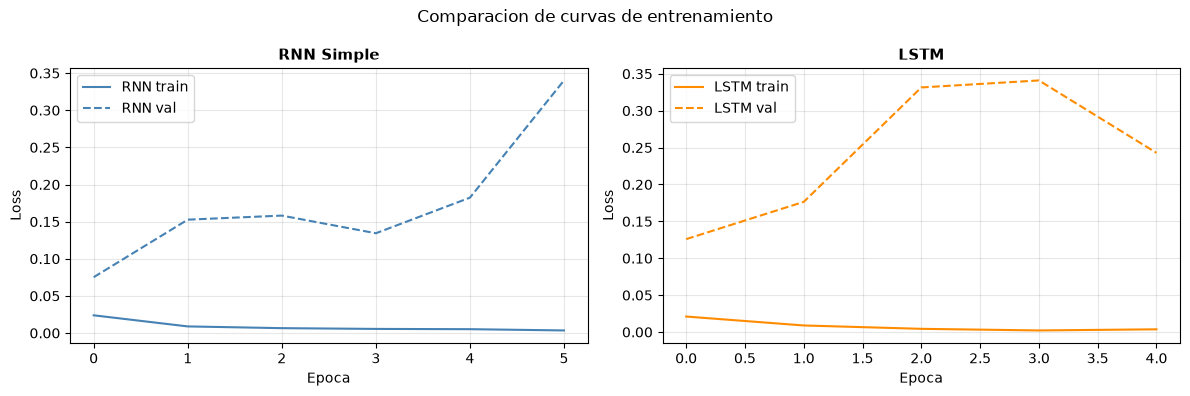

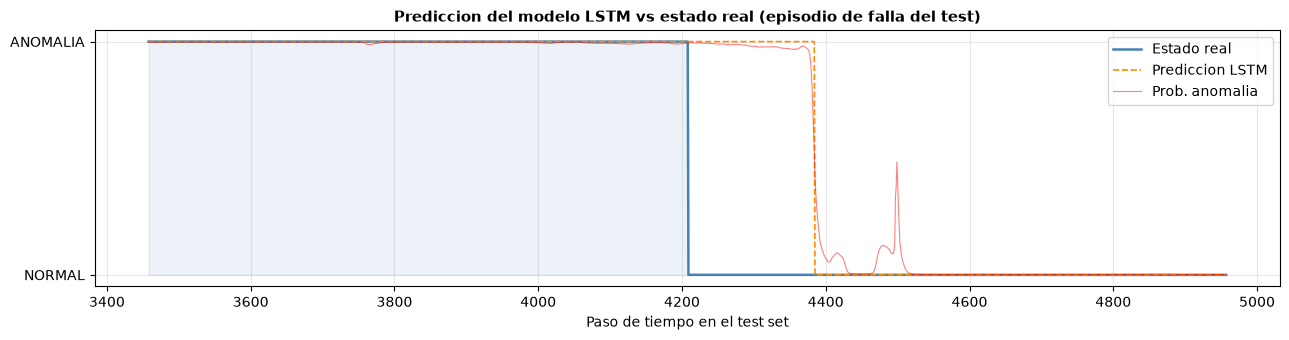

MODELO RNN SIMPLE
              precision    recall  f1-score   support

      Normal      1.000     0.977     0.988     83771
    Anomalia      0.694     0.994     0.818      4327

    accuracy                          0.978     88098
   macro avg      0.847     0.986     0.903     88098
weighted avg      0.985     0.978     0.980     88098

Matriz de confusion [filas=real, cols=pred]:
[[81877  1894]
 [   24  4303]]

MODELO LSTM
              precision    recall  f1-score   support

      Normal      1.000     0.988     0.994     83771
    Anomalia      0.805     0.998     0.891      4327

    accuracy                          0.988     88098
   macro avg      0.903     0.993     0.942     88098
weighted avg      0.990     0.988     0.989     88098

Matriz de confusion [filas=real, cols=pred]:
[[82728  1043]
 [   10  4317]]

Resumen para el informe / tabla 2.2:
  RNN   | accuracy=0.978 | P_anom=0.694 | R_anom=0.994 | F1_anom=0.818
  LSTM  | accuracy=0.988 | P_anom=0.805 | R_anom=0.998

In [9]:
# ============================================================
# FASE 2 — Bloque D: Comparacion de modelos
# Responsable: Integrante 3 con revision de Integrante 2
# [COMPLETAR]
# ============================================================

# --- Grafico 1: Curvas de loss de entrenamiento ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Comparacion de curvas de entrenamiento')

ax1.plot(historia_rnn.history['loss'],     label='RNN train', color='steelblue')
ax1.plot(historia_rnn.history['val_loss'], label='RNN val',   color='steelblue', linestyle='--')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Loss')
ax1.set_title('RNN Simple'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(historia_avanzado.history['loss'],     label='LSTM train', color='darkorange')
ax2.plot(historia_avanzado.history['val_loss'], label='LSTM val',   color='darkorange', linestyle='--')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Loss')
ax2.set_title('LSTM'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/fase2_curvas_loss.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Predicciones sobre el test set ---
# La salida sigmoide da la probabilidad de anomalia; se umbraliza en 0.5.
prob_rnn        = modelo_rnn.predict(X_test, batch_size=256, verbose=0).ravel()
prob_avanzado   = modelo_avanzado.predict(X_test, batch_size=256, verbose=0).ravel()
y_pred_rnn      = (prob_rnn      >= 0.5).astype(int)
y_pred_avanzado = (prob_avanzado >= 0.5).astype(int)

# --- Grafico 2: Prediccion vs realidad en un episodio del test set ---
# Se centra la ventana en la primera transicion de estado del test (donde se
# ve realmente la falla), en lugar de un tramo plano arbitrario.
transiciones = np.where(np.diff(y_test) != 0)[0]
centro = int(transiciones[0]) if len(transiciones) else len(y_test) // 2
lo = max(0, centro - 750)
hi = min(len(y_test), lo + 1500)
rango = np.arange(lo, hi)

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(rango, y_test[lo:hi],          label='Estado real',       color='steelblue', linewidth=1.8)
ax.plot(rango, y_pred_avanzado[lo:hi], label='Prediccion LSTM',   color='darkorange', linestyle='--', linewidth=1.2)
ax.plot(rango, prob_avanzado[lo:hi],   label='Prob. anomalia',    color='red', linewidth=0.8, alpha=0.5)
ax.fill_between(rango, 0, y_test[lo:hi], color='steelblue', alpha=0.10)
ax.set_yticks([0, 1]); ax.set_yticklabels(['NORMAL', 'ANOMALIA'])
ax.set_xlabel('Paso de tiempo en el test set')
ax.set_title('Prediccion del modelo LSTM vs estado real (episodio de falla del test)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/fase2_pred_vs_real.png', dpi=100, bbox_inches='tight')
plt.show()

# --- Metricas: classification_report para ambos modelos ---
# Enfasis en el RECALL de la clase anomalia: un recall bajo significa
# fallas reales no detectadas a tiempo (lo mas costoso operativamente).
NOMBRES_CLASES = ['Normal', 'Anomalia']

print("=" * 55)
print("MODELO RNN SIMPLE")
print("=" * 55)
print(classification_report(y_test, y_pred_rnn, target_names=NOMBRES_CLASES, digits=3))
print("Matriz de confusion [filas=real, cols=pred]:")
print(confusion_matrix(y_test, y_pred_rnn))

print("\n" + "=" * 55)
print("MODELO LSTM")
print("=" * 55)
print(classification_report(y_test, y_pred_avanzado, target_names=NOMBRES_CLASES, digits=3))
print("Matriz de confusion [filas=real, cols=pred]:")
print(confusion_matrix(y_test, y_pred_avanzado))

# --- Exportar resultados reales para el dashboard (Bonus) ---
import pickle
rep_rnn = classification_report(y_test, y_pred_rnn,      target_names=NOMBRES_CLASES, output_dict=True)
rep_lst = classification_report(y_test, y_pred_avanzado, target_names=NOMBRES_CLASES, output_dict=True)

ts_test = df['timestamp'].values[corte + LOOKBACK:]   # timestamps alineados con y_test
resultados = {
    'y_true':     y_test,
    'y_pred':     y_pred_avanzado,
    'y_prob':     np.column_stack([1 - prob_avanzado, prob_avanzado]),
    'timestamps': ts_test,
    'recall':     float(rep_lst['Anomalia']['recall']),
}
with open('resultados.pkl', 'wb') as f:
    pickle.dump(resultados, f)

print("\nResumen para el informe / tabla 2.2:")
for nombre, rep in [('RNN', rep_rnn), ('LSTM', rep_lst)]:
    a = rep['Anomalia']
    print(f"  {nombre:5s} | accuracy={rep['accuracy']:.3f} | "
          f"P_anom={a['precision']:.3f} | R_anom={a['recall']:.3f} | F1_anom={a['f1-score']:.3f}")
print("\nResultados exportados a resultados.pkl (para el dashboard de Streamlit).")

### Respuesta escrita 2.2 — Interpretacion de metricas

Valores obtenidos sobre el **test set** (88 098 ventanas; 4 327 de la clase anomalia):

| Metrica | RNN Simple | LSTM | Diferencia (LSTM − RNN) |
|---------|:---------:|:----:|:----------------------:|
| Accuracy global | 0.978 | 0.988 | +0.010 |
| Precision clase anomalia | 0.694 | 0.805 | +0.111 |
| Recall clase anomalia | 0.994 | 0.998 | +0.004 |
| F1-score clase anomalia | 0.818 | 0.891 | +0.073 |

Matriz de confusion (clase anomalia): la **RNN** deja **24 fallas sin detectar** y genera **1 894 falsas alarmas**; la **LSTM** deja **solo 10 sin detectar** y **1 043 falsas alarmas**.

**Interpretacion:**

Para mantenimiento predictivo la metrica mas importante es el **recall de la clase anomalia**: mide que fraccion de las fallas reales el modelo logra detectar. Un recall bajo significa fallas que pasan desapercibidas y terminan en una parada **correctiva** no planificada, el peor escenario operativo. Ambos modelos alcanzan un recall altisimo (RNN 0.994, LSTM 0.998), pero la **LSTM es superior en todas las metricas**, y sobre todo en **precision** (0.805 vs 0.694): a igual capacidad de detectar fallas, la LSTM genera casi la mitad de falsas alarmas (1 043 vs 1 894).

El **trade-off precision/recall** aqui es asimetrico: **no detectar una falla real (falso negativo)** es mucho mas costoso —dano al equipo, parada no programada, perdida de produccion— que **una falsa alarma (falso positivo)**, que a lo sumo cuesta una inspeccion preventiva innecesaria. Por eso se prioriza un recall alto aun a costa de algo de precision. La LSTM es la mejor opcion porque mantiene ese recall casi perfecto **y** reduce las falsas alarmas, que es lo que hace al sistema usable en planta (un exceso de falsas alarmas lleva a que los operarios terminen ignorando el sistema).

---
## FASE 3 — Analisis de gradientes
**Responsable principal:** Integrante 2  
**Puntaje:** 3 puntos  
**Tiempo estimado:** 10 minutos

Esta fase no requiere codigo. Las respuestas se escriben en las celdas Markdown siguientes.

### Rubrica

| Criterio | Puntos |
|----------|--------|
| Explicacion correcta del vanishing gradient con BPTT | 1.5 |
| Propuesta de LOOKBACK alternativo con argumento valido | 1.5 |
| **Total Fase 3** | **3.0** |

### Pregunta 3.1 — Vanishing Gradient en BPTT

El gradiente de la perdida respecto a los pesos de una RNN en el paso $t$ se calcula propagando hacia atras a traves del tiempo:

$$\frac{\partial L}{\partial W} = \sum_{t} \frac{\partial L_t}{\partial h_t} \prod_{k=t+1}^{T} \frac{\partial h_k}{\partial h_{k-1}}$$

**a) Que ocurre con el producto cuando $\left\|\frac{\partial h_k}{\partial h_{k-1}}\right\| < 1$ para muchos pasos $k$?**

El producto es una multiplicacion encadenada de muchos factores, todos con norma menor que 1. Multiplicar repetidamente numeros < 1 hace que el resultado decaiga de forma **exponencial** hacia 0 a medida que crece la distancia temporal $(T - t)$. Es decir, $\prod \frac{\partial h_k}{\partial h_{k-1}} \to 0$. Este es el fenomeno de **vanishing gradient** (desvanecimiento del gradiente): la contribucion de los pasos lejanos a la actualizacion de los pesos se vuelve practicamente nula. (El caso simetrico, factores > 1, produce *exploding gradient*.)

**b) Que consecuencia practica tiene sobre la deteccion de RECOVERING cuando precede a la falla por mas de 20 pasos?**

Como el gradiente que llega desde los pasos lejanos es ≈ 0, durante el entrenamiento la RNN **casi no recibe senal de aprendizaje** que conecte lo que paso hace 20-30 minutos con la etiqueta del instante actual. En la practica la red solo logra aprender dependencias de **corto plazo** (los ultimos pocos pasos) y es **incapaz de asociar el inicio sutil de la degradacion** —que es lo que define `RECOVERING`— con la anomalia que aparece decenas de pasos despues. El modelo termina reaccionando tarde, justo lo contrario del objetivo de mantenimiento predictivo: anticipar la falla.

**c) Como lo resuelve la arquitectura elegida (LSTM)? Mecanismo concreto.**

La LSTM introduce una **celda de memoria** $C_t$ que se actualiza de forma **aditiva**:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
donde $f_t$ (forget gate) e $i_t$ (input gate) son compuertas aprendidas. La derivada $\frac{\partial C_t}{\partial C_{t-1}} \approx f_t$ en lugar de un jacobiano denso multiplicado por pesos. Cuando la forget gate se mantiene cerca de 1, la informacion se transporta por la celda **sin atenuarse**, creando un *constant error carousel*: el gradiente fluye hacia atras a traves de la suma sin quedar atrapado en productos de factores < 1. Asi la LSTM **preserva el gradiente durante decenas de pasos** y puede aprender la dependencia larga entre el inicio de la degradacion y la falla. La GRU logra el mismo efecto con su *update gate*, que interpola aditivamente entre el estado anterior y el candidato nuevo.

### Pregunta 3.2 — Seleccion del LOOKBACK optimo

En Fase 2 se uso `LOOKBACK = 30` minutos.

**a) Valor alternativo de LOOKBACK y argumento.**

Se propone **aumentar el LOOKBACK a 60-120 minutos**. En los graficos de series temporales de Fase 1 se observa que la transicion `NORMAL → RECOVERING` no es un salto brusco: la degradacion de varios sensores empieza a manifestarse como una **deriva lenta** (cambio de nivel o de variabilidad) que se desarrolla a lo largo de **mucho mas de 30 minutos** antes de que el sistema etiquete formalmente el estado. Con una ventana de solo 30 pasos, el modelo ve apenas el final de esa deriva y puede confundirlo con ruido normal. Una ventana mas larga (60-120 min) le da **mas contexto historico** para reconocer la tendencia completa y, por tanto, anticipar la falla con mayor margen y mejor *recall* sobre la clase anomalia. El valor exacto deberia validarse comparando el recall de anomalia para varios LOOKBACK (p. ej. 30, 60, 120) y eligiendo el que maximice la deteccion temprana sin degradar la precision.

*(Nota: tambien seria razonable un LOOKBACK menor si el unico objetivo fuera reducir latencia/computo, pero para deteccion **anticipada** conviene mas contexto.)*

**b) Riesgo computacional de aumentar excesivamente el LOOKBACK en una RNN simple.**

1. **Costo y memoria:** el BPTT debe desenrollar la red tantos pasos como el LOOKBACK; el tiempo de entrenamiento y la memoria crecen aproximadamente de forma **lineal con la longitud de la ventana**, encareciendo cada epoca.
2. **Vanishing gradient (lo mas grave en una RNN *simple*):** cuanto mas larga la secuencia, mas factores < 1 se multiplican en el producto del gradiente (ver 3.1), por lo que el gradiente se desvanece y la RNN simple **no logra aprovechar** los pasos lejanos —la ventana mas grande no se traduce en mejor deteccion, e incluso puede empeorar la convergencia—. Por eso, para ventanas largas conviene precisamente una **LSTM/GRU**, no una RNN simple.

---
## FASE 4 — Presentacion ejecutiva
**Responsable principal:** Integrante 4  
**Puntaje:** 4 puntos  
**Tiempo estimado:** 10 minutos de preparacion + 3 minutos de exposicion oral

### Rubrica

| Criterio | Puntos |
|----------|--------|
| Claridad: ausencia de jerga tecnica innecesaria | 1.5 |
| Precision: los datos del notebook se reflejan correctamente | 1.5 |
| Coherencia entre resultados y recomendacion operativa | 1.0 |
| **Total Fase 4** | **4.0** |

### Contenido requerido por diapositiva

Preparar 4 diapositivas en Google Slides, PowerPoint o Canva, dirigidas al **gerente de planta** (no al equipo tecnico). Compartir el enlace o adjuntar el archivo al notebook.

| Diapositiva | Titulo sugerido | Contenido obligatorio |
|-------------|-----------------|----------------------|
| 1 | El problema en numeros | Frecuencia de fallas en el dataset; costo estimado de parada correctiva vs preventiva (el grupo puede asumir un costo por hora de parada) |
| 2 | Como funciona el modelo | Analogia visual del lookback; que señal de los sensores detecta antes de la falla |
| 3 | Que tan confiable es | Recall de la clase anomalia en lenguaje llano; grafico de prediccion vs estado real en un episodio del test set |
| 4 | Que falta antes de produccion | Al menos 3 limitaciones concretas; propuesta de siguiente paso |

### Enlace a las diapositivas

### Enlace a las diapositivas

*(Pegar aqui el enlace de Google Slides / Canva. El contenido obligatorio de cada una de las 4 laminas se detalla abajo, ya con los numeros reales del notebook para montarlas.)*

---

**Diapositiva 1 — El problema en numeros**
- La bomba registro **7 episodios de falla** en ~5 meses de operacion (abril–agosto 2018, datos de 1 minuto).
- La maquina estuvo en estado de anomalia/recuperacion el **6.6 %** del tiempo.
- Cada falla no anticipada = parada **correctiva** (no planificada), mas cara que una intervencion **preventiva** programada. *(Ejemplo asumible: si 1 h de parada cuesta US$ 5 000 y una falla no detectada implica ~6 h fuera de servicio → ~US$ 30 000 por evento; anticiparla lo reduce a una intervencion planificada de pocas horas.)*

**Diapositiva 2 — Como funciona el modelo**
- El modelo "mira" los **ultimos 30 minutos** de los 49 sensores antes de cada instante (analogia: no juzga por una sola foto, sino por la **evolucion reciente** de los signos vitales del equipo).
- Aprende a reconocer la **deriva temprana** de las señales (vibracion, temperatura o presion que empiezan a desviarse) **antes** de que la bomba falle.

**Diapositiva 3 — Que tan confiable es**
- De cada **100 fallas reales, el modelo detecta ~99.8** (recall 99.8 %): casi no se le escapa ninguna (solo 10 de 4 327 ventanas de falla en la prueba).
- De cada 100 alertas, ~80 corresponden a fallas reales (precision 80 %); el resto son falsas alarmas que se resuelven con una inspeccion rapida.
- Insertar el grafico `results/fase2_pred_vs_real.png` (prediccion del modelo vs estado real en un episodio de falla del periodo de prueba).

**Diapositiva 4 — Que falta antes de produccion**
1. **Datos de una sola bomba y pocos episodios (7 fallas):** validar con mas equipos y mas eventos para confirmar que generaliza.
2. **Umbral de alerta por calibrar con operaciones:** hoy 0.5; moverlo cambia el balance entre falsas alarmas y detecciones (el dashboard permite simularlo en vivo).
3. **Posible cambio de comportamiento en el tiempo (concept drift):** requiere reentrenamiento periodico y monitoreo del desempeño en produccion.
- **Siguiente paso propuesto:** piloto de 1–2 meses en *shadow mode* (en paralelo a la operacion actual), midiendo cuantas fallas habria anticipado y con cuanto margen, antes de conectarlo a alertas reales.

---
## BONUS — Dashboard interactivo con Streamlit
**Puntaje adicional:** 2 puntos (fuera del tiempo del examen)  
**Plazo de entrega:** 48 horas despues del examen

Implementar el archivo `dashboard_bomba.py` usando la plantilla base proporcionada a continuacion. El grupo debe reemplazar los placeholders con los resultados reales obtenidos en Fase 2.

**Criterio de evaluacion del bonus:**
- El dashboard corre sin errores y muestra datos reales del modelo: 1 pt
- El semaforo de alerta cambia correctamente segun el umbral del slider: 1 pt

In [10]:
# ============================================================
# BONUS — Plantilla del dashboard (version mejorada)
# Guardar este codigo como dashboard_bomba.py
# Ejecutar con: streamlit run dashboard_bomba.py
# ============================================================

# Escribe dashboard_bomba.py. Carga resultados.pkl (datos reales de Fase 2):
# metricas EN VIVO segun el umbral, matriz de confusion, curva precision-recall
# y navegacion por episodios de falla. Respaldo de demostracion si falta el pkl.

PLANTILLA_DASHBOARD = r'''import os
import pickle
import numpy as np
import pandas as pd
import streamlit as st
import plotly.graph_objects as go

st.set_page_config(
    page_title="Monitor de Bomba — Mantenimiento Predictivo",
    page_icon="\U0001F6A6", layout="wide"
)

# ============================================================
# Carga de datos (cacheada) + utilidades
# ============================================================
@st.cache_data
def cargar_datos():
    if os.path.exists("resultados.pkl"):
        with open("resultados.pkl", "rb") as f:
            R = pickle.load(f)
        y_true = np.asarray(R["y_true"]).astype(int)
        y_prob = np.asarray(R["y_prob"])[:, 1].astype(float)
        ts = pd.to_datetime(R["timestamps"])
        return y_true, y_prob, ts, True
    # Respaldo de demostracion si no existe resultados.pkl
    n = 4000
    rng = np.random.default_rng(0)
    y_true = np.zeros(n, dtype=int)
    y_true[1500:1850] = 1
    y_true[3000:3120] = 1
    y_prob = np.clip(rng.uniform(0, 0.2, n) + y_true * rng.uniform(0.6, 0.9, n), 0, 1)
    ts = pd.date_range("2018-07-01", periods=n, freq="1min")
    return y_true, y_prob, ts, False


def metricas(yt, prob, thr):
    pred = prob >= thr
    tp = int((pred & (yt == 1)).sum())
    fp = int((pred & (yt == 0)).sum())
    fn = int((~pred & (yt == 1)).sum())
    tn = int((~pred & (yt == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    acc = (tp + tn) / len(yt) if len(yt) else 0.0
    return dict(tp=tp, fp=fp, fn=fn, tn=tn, prec=prec, rec=rec, f1=f1, acc=acc)


def episodios(yt):
    idx = np.where(yt == 1)[0]
    if len(idx) == 0:
        return []
    brk = np.where(np.diff(idx) > 1)[0]
    ini = np.concatenate([[idx[0]], idx[brk + 1]])
    fin = np.concatenate([idx[brk], [idx[-1]]])
    return list(zip(ini.tolist(), fin.tolist()))


def runs_anomalia(yt):
    """Tramos contiguos donde yt==1 (para sombrear el grafico)."""
    out, i, n = [], 0, len(yt)
    while i < n:
        if yt[i] == 1:
            j = i
            while j < n and yt[j] == 1:
                j += 1
            out.append((i, j - 1))
            i = j
        else:
            i += 1
    return out


y_true, y_prob, ts, datos_reales = cargar_datos()
N = len(y_true)
eps = episodios(y_true)
m = None  # se calcula tras leer el umbral

# ============================================================
# Sidebar
# ============================================================
st.sidebar.header("⚙️ Configuración del operador")
umbral = st.sidebar.slider("Umbral de probabilidad para alerta", 0.05, 0.95, 0.50, 0.05)
if datos_reales:
    st.sidebar.success("Datos reales del modelo (resultados.pkl)")
else:
    st.sidebar.warning("resultados.pkl no encontrado: datos de demostración")

opciones = ["Zona más crítica"] + [
    f"Episodio {i+1} — {ts[s].strftime('%d/%b %H:%M')} ({e - s + 1} min)"
    for i, (s, e) in enumerate(eps)
]
sel = st.sidebar.selectbox("Ver episodio de falla", opciones)
ventana = st.sidebar.slider("Ancho de ventana (pasos = minutos)", 200, 4000, 1500, 100)

if sel == "Zona más crítica" or not eps:
    centro = int(np.argmax(y_prob)) if N else 0
else:
    s, e = eps[opciones.index(sel) - 1]
    centro = (s + e) // 2
ini = max(0, centro - ventana // 2)
fin = min(N, ini + ventana)
ini = max(0, fin - ventana)

# ============================================================
# Encabezado + KPIs (reaccionan al umbral)
# ============================================================
st.title("\U0001F6A6 Sistema de Alerta Temprana — Bomba Industrial")
st.caption(
    "Modelo LSTM · datos reales (Kaggle: pump_sensor_data) · "
    f"{N:,} ventanas de prueba, {int(y_true.sum()):,} de falla"
)

m = metricas(y_true, y_prob, umbral)
m50 = metricas(y_true, y_prob, 0.50)
estado = "ANOMALÍA" if (N and y_prob[fin - 1] >= umbral) else "NORMAL"
color = "#d32f2f" if estado == "ANOMALÍA" else "#2e7d32"

c0, c1, c2, c3 = st.columns([1.4, 1, 1, 1])
with c0:
    st.markdown(
        f"<div style='background:{color};padding:18px;border-radius:10px;"
        f"text-align:center;color:#fff;font-size:19px;font-weight:700;'>"
        f"Estado actual<br>{estado}</div>",
        unsafe_allow_html=True,
    )
    if N:
        st.caption(f"Prob. anomalía (último punto de la ventana): {y_prob[fin-1]:.0%}")
c1.metric("Recall — fallas detectadas", f"{m['rec']:.1%}",
          f"{(m['rec']-m50['rec'])*100:+.1f} pp vs 0.50",
          help="De todas las fallas reales, cuántas detecta. Lo más crítico en mantenimiento predictivo.")
c2.metric("Precisión — alertas acertadas", f"{m['prec']:.1%}",
          f"{(m['prec']-m50['prec'])*100:+.1f} pp vs 0.50",
          help="De todas las alertas que emite, cuántas eran fallas reales.")
c3.metric("Fallas NO detectadas", f"{m['fn']:,}",
          f"{m['fn']-m50['fn']:+d} vs 0.50", delta_color="inverse",
          help="Falsos negativos: el peor caso operativo.")

st.divider()

tab_mon, tab_perf = st.tabs(["\U0001F4CA Monitor en vivo", "\U0001F4C8 Rendimiento del modelo"])

# ============================================================
# Tab 1 — Monitor en vivo
# ============================================================
with tab_mon:
    wt = ts[ini:fin]
    wy = y_true[ini:fin]
    wp = y_prob[ini:fin]
    wpred = (wp >= umbral).astype(int)

    fig = go.Figure()
    # sombrear episodios reales de falla dentro de la ventana
    for a, b in runs_anomalia(wy):
        fig.add_vrect(x0=wt[a], x1=wt[b], fillcolor="#d32f2f", opacity=0.10, line_width=0)
    fig.add_trace(go.Scatter(x=wt, y=wy, mode="lines", name="Estado real",
                             line=dict(color="steelblue", width=1.8)))
    fig.add_trace(go.Scatter(x=wt, y=wpred, mode="lines", name="Predicción modelo",
                             line=dict(color="darkorange", width=1.4, dash="dot")))
    fig.add_trace(go.Scatter(x=wt, y=wp, mode="lines", name="Prob. anomalía",
                             line=dict(color="#c62828", width=1), opacity=0.55))
    fig.add_hline(y=umbral, line_dash="dot", line_color="gray",
                  annotation_text=f"Umbral {umbral:.2f}")
    fig.update_layout(
        xaxis_title="Tiempo",
        yaxis=dict(tickvals=[0, 1], ticktext=["NORMAL", "ANOMALÍA"], range=[-0.05, 1.1]),
        legend=dict(orientation="h", y=-0.25), height=380,
        margin=dict(l=40, r=20, t=10, b=20),
    )
    st.plotly_chart(fig, width="stretch")

    a, b, c = st.columns(3)
    a.metric("Alertas en la ventana", int(wpred.sum()))
    b.metric("Falsas alarmas en la ventana", int(((wpred == 1) & (wy == 0)).sum()))
    c.metric("Minutos de falla reales en la ventana", int(wy.sum()))
    st.caption("Franja roja = episodio de falla real. La predicción y las métricas de arriba "
               "cambian al mover el umbral en la barra lateral.")

# ============================================================
# Tab 2 — Rendimiento del modelo (sobre TODO el test)
# ============================================================
with tab_perf:
    izq, der = st.columns([1, 1.2])

    with izq:
        st.markdown("**Matriz de confusión** (% por clase real)")
        cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]], dtype=float)
        fila = cm.sum(axis=1, keepdims=True)
        cm_pct = np.divide(cm, fila, out=np.zeros_like(cm), where=fila != 0) * 100
        txt = [[f"{cm_pct[i, j]:.1f}%<br>({int(cm[i, j]):,})" for j in range(2)]
               for i in range(2)]
        figcm = go.Figure(go.Heatmap(
            z=cm_pct, x=["Pred. NORMAL", "Pred. ANOMALÍA"],
            y=["Real NORMAL", "Real ANOMALÍA"],
            text=txt, texttemplate="%{text}", zmin=0, zmax=100,
            colorscale="Blues", showscale=False, hoverinfo="skip"))
        figcm.update_layout(height=260, margin=dict(l=10, r=10, t=10, b=10),
                            yaxis=dict(autorange="reversed"))
        st.plotly_chart(figcm, width="stretch")
        st.caption("Cada fila suma 100% (porcentaje de cada clase real); entre paréntesis, "
                   "el conteo. La celda inferior derecha es el recall.")
        st.metric("Accuracy global", f"{m['acc']:.2%}")
        st.metric("F1-score (anomalía)", f"{m['f1']:.3f}")

    with der:
        st.markdown("**Precisión y Recall según el umbral**")
        ths = np.round(np.arange(0.05, 0.96, 0.05), 2)
        precs, recs = [], []
        for t in ths:
            mm = metricas(y_true, y_prob, float(t))
            precs.append(mm["prec"]); recs.append(mm["rec"])
        figpr = go.Figure()
        figpr.add_trace(go.Scatter(x=ths, y=recs, name="Recall",
                                   line=dict(color="#1565c0", width=2)))
        figpr.add_trace(go.Scatter(x=ths, y=precs, name="Precisión",
                                   line=dict(color="#ff8c00", width=2)))
        figpr.add_vline(x=umbral, line_dash="dot", line_color="gray",
                        annotation_text=f"{umbral:.2f}")
        figpr.update_layout(xaxis_title="Umbral", yaxis_title="Valor",
                            yaxis_range=[0, 1.02], height=300,
                            legend=dict(orientation="h", y=-0.3),
                            margin=dict(l=40, r=20, t=10, b=20))
        st.plotly_chart(figpr, width="stretch")
        st.caption("Subir el umbral aumenta la precisión pero reduce el recall (menos falsas "
                   "alarmas, pero más fallas podrían escaparse). El punto de operación se elige "
                   "con el área de confiabilidad según el costo de cada error.")

st.divider()
st.caption("Prototipo académico (examen DL_TA4). No usar en producción sin validación adicional.")
'''

with open('dashboard_bomba.py', 'w') as f:
    f.write(PLANTILLA_DASHBOARD)

print('Plantilla guardada como dashboard_bomba.py')
print('Ejecutar con: streamlit run dashboard_bomba.py')
print('Usa resultados.pkl (datos reales) generado en Fase 2.')


Plantilla guardada como dashboard_bomba.py
Ejecutar con: streamlit run dashboard_bomba.py
Usa resultados.pkl (datos reales) generado en Fase 2.


---
## Resumen de puntaje

**[Para uso del docente — no modificar]**

| Fase | Criterio | Puntaje maximo | Puntaje obtenido |
|------|----------|:--------------:|:----------------:|
| 1 | Seleccion de sensores y NaN | 1.0 | |
| 1 | Grafico de series temporales | 1.0 | |
| 1 | Decision sobre BROKEN | 1.0 | |
| 1 | Justificacion modelado secuencial | 1.0 | |
| 2 | Ventanas temporales sin data leakage | 2.0 | |
| 2 | Modelo RNN funcional | 2.0 | |
| 2 | Modelo LSTM/GRU funcional | 2.0 | |
| 2 | Comparacion de metricas | 2.0 | |
| 2 | Justificacion LSTM vs GRU | 1.0 | |
| 3 | Vanishing gradient (BPTT) | 1.5 | |
| 3 | LOOKBACK optimo | 1.5 | |
| 4 | Claridad de comunicacion | 1.5 | |
| 4 | Precision de contenidos | 1.5 | |
| 4 | Coherencia resultados-recomendacion | 1.0 | |
| **Total** | | **20.0** | |
| Bonus | Dashboard Streamlit | +2.0 | |

---

